In [44]:
from google.colab import files

uploaded = files.upload()

Saving used_cars.csv to used_cars (1).csv


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv("used_cars.csv")

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999


#  Understand the dataset

In [47]:
print("Shape of dataset:", df.shape)

Shape of dataset: (4009, 12)


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   int64 
dtypes: int64(2), object(10)
memory usage: 376.0+ KB


In [49]:
df.describe(include="all")

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009.000000,4009,3839,4009,4009,4009,4009,3896,3413,4.009000e+03
unique,57,1898,NaN,2818,7,1146,62,319,156,2,1,NaN
top,Ford,M3 Base,NaN,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,NaN
freq,386,30,NaN,16,3309,52,1037,905,2025,2910,3413,NaN
mean,NaN,NaN,2015.515590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.455319e+04
std,NaN,NaN,6.104816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.871064e+04
min,NaN,NaN,1974.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+03
25%,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.720000e+04
50%,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.100000e+04
75%,NaN,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.999000e+04


In [50]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [51]:
df.head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,14798
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,7300
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,41927
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,69950


# Check numerical and categorical columns

In [52]:
numerical_features = df.select_dtypes(include=np.number).columns
categorical_features = df.select_dtypes(include="object").columns

print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['model_year', 'price']

Categorical Features:
['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']


# Check missing values


In [53]:
missing_values = df.isnull().sum()

print(missing_values)

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


In [54]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
clean_title,596,14.866550
fuel_type,170,4.240459
accident,113,2.818658
brand,0,0.000000
milage,0,0.000000
model_year,0,0.000000
model,0,0.000000
engine,0,0.000000
ext_col,0,0.000000
transmission,0,0.000000


# Check duplicate records

In [55]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [56]:
df = df.drop_duplicates()

In [57]:
print("Duplicates after removal:", df.duplicated().sum())

Duplicates after removal: 0


# Check unique values

In [58]:
for col in categorical_features:
    print("\nColumn:", col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


Column: brand
Unique values: 57
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Name: count, dtype: int64

Column: model
Unique values: 1898
model
M3 Base               30
F-150 XLT             24
Corvette Base         22
1500 Laramie          18
Camaro 2SS            17
Wrangler Sport        17
Model Y Long Range    17
Mustang GT Premium    16
911 Carrera           16
M4 Base               15
Name: count, dtype: int64

Column: milage
Unique values: 2818
milage
110,000 mi.    16
45,000 mi.     15
120,000 mi.    13
55,000 mi.     13
54,000 mi.     12
60,000 mi.     12
92,000 mi.     12
40,000 mi.     12
65,000 mi.     12
73,000 mi.     11
Name: count, dtype: int64

Column: fuel_type
Unique values: 7
fuel_type
Gasoline           3309
Hybrid              194
E85 Flex Fuel       139
Diesel              116
â_x0080__x0093_  

# Analyze distributions

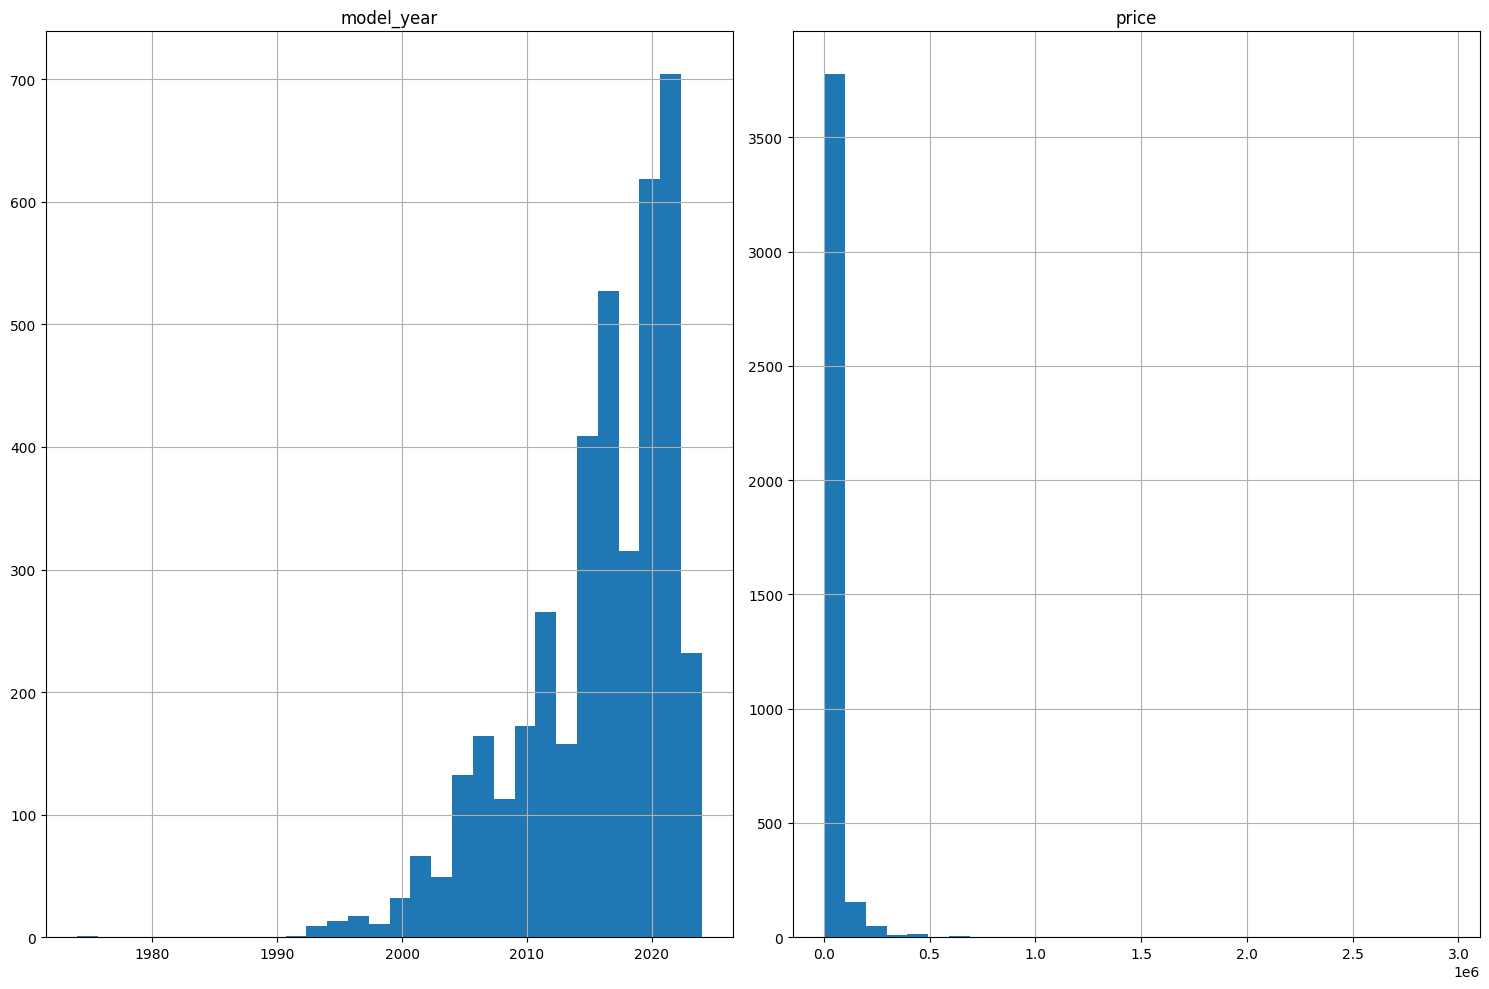

In [59]:
df[numerical_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

In [60]:
df.columns.tolist()

['brand',
 'model',
 'model_year',
 'milage',
 'fuel_type',
 'engine',
 'transmission',
 'ext_col',
 'int_col',
 'accident',
 'clean_title',
 'price']

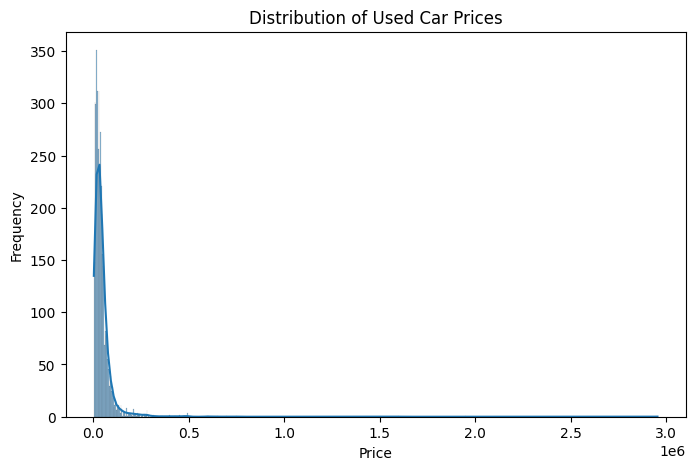

In [61]:
plt.figure(figsize=(8, 5))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

# Identify outliers

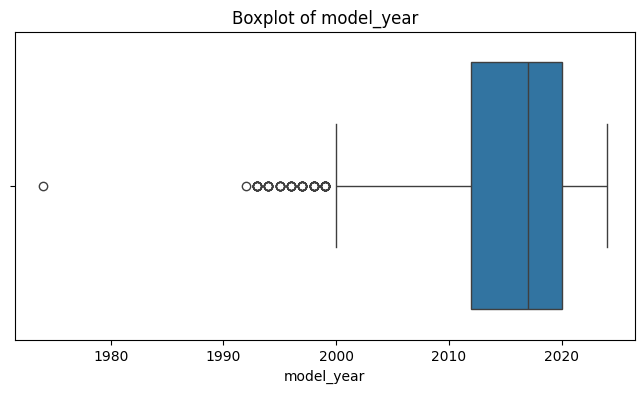

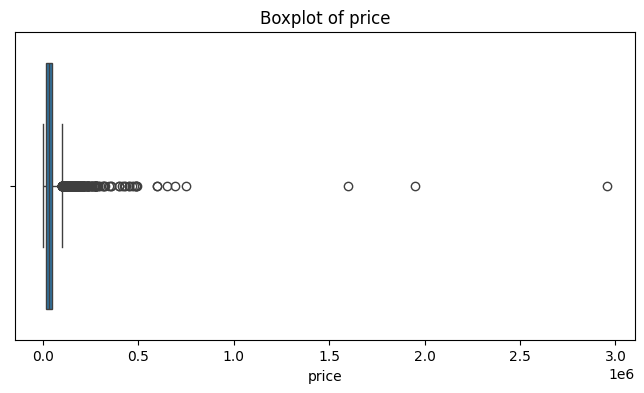

In [63]:
for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [64]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

for col in numerical_features:
    outliers = detect_outliers_iqr(df, col)
    print(col, ":", len(outliers), "outliers")

model_year : 67 outliers
price : 244 outliers


# Data Cleaning

In [65]:
df = df.drop_duplicates()

# Fix column names

In [66]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [67]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

# Handle missing values

In [68]:
for col in numerical_features:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [69]:
for col in categorical_features:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Correct data types

In [70]:
df.dtypes

,0
brand,object
model,object
model_year,int64
milage,object
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


In [74]:
df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)

# Feature Engineering

In [80]:
print(df.columns.tolist())

['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price', 'car_age']


In [81]:
print(df.head())

      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2     Lexus                    RX 350 RX 350        2022  22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015  88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021   9,835 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission                 ext_col int_col  \
0        6-Speed A/T                   Black   Black   
1  8-Speed Automatic        

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     4009 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      4009 non-null   object
 10  clean_title   4009 non-null   object
 11  price         4009 non-null   int64 
 12  car_age       4009 non-null   int64 
dtypes: int64(3), object(10)
memory usage: 407.3+ KB


In [83]:
df["milage"] = (
    df["milage"]
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .astype(float)
)

In [84]:
df[["milage"]].head()

,milage
0,51000.0
1,34742.0
2,22372.0
3,88900.0
4,9835.0


In [85]:
print(df["price"].dtype)

int64


In [86]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# 5 engineering faeatures

In [87]:
df["mileage_per_year"] = (
    df["milage"] / df["car_age"].replace(0, 1)
)

In [88]:
df["engine_liters"] = (
    df["engine"]
    .str.extract(r"(\d+\.\d+)\s*[Ll]")
    .astype(float)
)

In [89]:
df[["engine", "engine_liters"]].head()

,engine,engine_liters
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,3.7
1,3.8L V6 24V GDI DOHC,3.8
2,3.5 Liter DOHC,3.5
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,3.5
4,2.0L I4 16V GDI DOHC Turbo,2.0


# 3

In [90]:
df["horsepower"] = (
    df["engine"]
    .str.extract(r"(\d+(?:\.\d+)?)HP")
    .astype(float)
)

In [91]:
df[["engine", "horsepower"]].head()

,engine,horsepower
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,300.0
1,3.8L V6 24V GDI DOHC,NaN
2,3.5 Liter DOHC,NaN
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,354.0
4,2.0L I4 16V GDI DOHC Turbo,NaN


# 4

In [92]:
df["has_accident"] = (
    df["accident"]
    .str.contains("At least 1 accident", case=False, na=False)
    .astype(int)
)

In [93]:
df[["accident", "has_accident"]].head()

,accident,has_accident
0,At least 1 accident or damage reported,1
1,At least 1 accident or damage reported,1
2,None reported,0
3,None reported,0
4,None reported,0


# 5

In [94]:
df["is_turbo"] = (
    df["engine"]
    .str.contains("Turbo", case=False, na=False)
    .astype(int)
)

# Check missing values created during feature engineering

In [95]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


In [96]:
for col in ["engine_liters", "horsepower", "mileage_per_year"]:
    df[col] = df[col].fillna(df[col].median())

# Check duplicates

In [97]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [98]:
df = df.drop_duplicates()

# Check for missing values

In [99]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing.sort_values(
    "Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
brand,0,0.0
model,0,0.0
model_year,0,0.0
milage,0,0.0
fuel_type,0,0.0
engine,0,0.0
transmission,0,0.0
ext_col,0,0.0
int_col,0,0.0
accident,0,0.0


# Check your final dataset


In [100]:
print("Final dataset shape:", df.shape)

df.head()

Final dataset shape: (4009, 18)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,mileage_per_year,engine_liters,horsepower,has_accident,is_turbo
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,13,3923.076923,3.7,300.0,1,0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,5,6948.400000,3.8,310.0,1,0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Yes,54598.0,4,5593.000000,3.5,310.0,0,0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,11,8081.818182,3.5,354.0,0,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Yes,34999.0,5,1967.000000,2.0,310.0,0,1


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             4009 non-null   object 
 1   model             4009 non-null   object 
 2   model_year        4009 non-null   int64  
 3   milage            4009 non-null   float64
 4   fuel_type         4009 non-null   object 
 5   engine            4009 non-null   object 
 6   transmission      4009 non-null   object 
 7   ext_col           4009 non-null   object 
 8   int_col           4009 non-null   object 
 9   accident          4009 non-null   object 
 10  clean_title       4009 non-null   object 
 11  price             4009 non-null   float64
 12  car_age           4009 non-null   int64  
 13  mileage_per_year  4009 non-null   float64
 14  engine_liters     4009 non-null   float64
 15  horsepower        4009 non-null   float64
 16  has_accident      4009 non-null   int64  


# Save the cleaned dataset

In [102]:
df.to_csv(
    "cleaned_used_cars.csv",
    index=False
)

In [103]:
from google.colab import files

files.download("cleaned_used_cars.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>